Install packages

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn plotly joblib openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\syedm\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


import libraries

In [3]:
import sys
!{sys.executable} -m pip install plotly

You should consider upgrading via the 'c:\Users\syedm\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
import plotly.express as px
import plotly.graph_objects as go

print("Plotly is working!")

Plotly is working!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

import joblib
import os

# upload dataset

In [8]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [10]:
df.shape

(10194, 18)

In [11]:
import pandas as pd

df = pd.read_csv("Nassau Candy Distributor.csv")

print(df.head())
print("Dataset Shape:", df.shape)

   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1       60540  Chocola

# inspect dataset

In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print(col)

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Rows: 10194
Columns: 18

Column Names:
Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Country/Region
City
State/Province
Postal Code
Division
Region
Product ID
Product Name
Sales
Units
Gross Profit
Cost

Data Types:


Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


Missing Values:


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

# clean cloumn names

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Country_Region', 'City', 'State_Province', 'Postal_Code', 'Division', 'Region', 'Product_ID', 'Product_Name', 'Sales', 'Units', 'Gross_Profit', 'Cost']


# convert dates

In [16]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

df["Ship_Date"] = pd.to_datetime(
    df["Ship_Date"],
    errors="coerce"
)

df["Shipping_Lead_Time"] = (
    df["Ship_Date"] - df["Order_Date"]
).dt.days

print(df[["Order_Date", "Ship_Date", "Shipping_Lead_Time"]].head())

  Order_Date  Ship_Date  Shipping_Lead_Time
0 2024-03-01 2026-06-30               851.0
1 2024-04-01 2026-07-01               821.0
2 2024-04-01 2026-07-01               821.0
3 2024-04-01 2026-07-01               821.0
4 2024-05-01 2026-07-05               795.0


# remove invalid records

In [17]:
df = df.dropna(
    subset=[
        "Order_Date",
        "Ship_Date",
        "Product_Name",
        "Sales",
        "Units",
        "Gross_Profit",
        "Cost"
    ]
)

df = df[df["Shipping_Lead_Time"] >= 0]

df = df[df["Units"] > 0]

df = df[df["Sales"] >= 0]

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (4130, 19)


# feature engineering

In [18]:
df["Profit_Margin"] = np.where(
    df["Sales"] != 0,
    df["Gross_Profit"] / df["Sales"],
    0
)

df["Sales_Per_Unit"] = np.where(
    df["Units"] != 0,
    df["Sales"] / df["Units"],
    0
)

df["Cost_Per_Unit"] = np.where(
    df["Units"] != 0,
    df["Cost"] / df["Units"],
    0
)

df["Profit_Per_Unit"] = np.where(
    df["Units"] != 0,
    df["Gross_Profit"] / df["Units"],
    0
)

df["Order_Month"] = df["Order_Date"].dt.month

df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek

df["Order_Year"] = df["Order_Date"].dt.year

display(df.head())

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Country_Region,City,State_Province,Postal_Code,...,Gross_Profit,Cost,Shipping_Lead_Time,Profit_Margin,Sales_Per_Unit,Cost_Per_Unit,Profit_Per_Unit,Order_Month,Order_DayOfWeek,Order_Year
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,4.22,2.28,851.0,0.649231,3.25,1.14,2.11,3,4,2024
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,4.90,2.60,821.0,0.653333,3.75,1.30,2.45,4,0,2024
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.47,3.00,821.0,0.713467,3.49,1.00,2.49,4,0,2024
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,3.30,821.0,0.694444,3.60,1.10,2.50,4,0,2024
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,7.35,3.90,795.0,0.653333,3.75,1.30,2.45,5,2,2024


# EDA

In [19]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row_ID,4130.0,NaN,NaN,NaN,5088.483535,1.0,2524.25,5132.5,7783.75,9961.0,2967.744182
Order_ID,4130,3462,US-2024-157987-CHO-NUT-13000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,4130,NaN,NaN,NaN,2025-01-25 22:38:45.617433600,2024-01-02 00:00:00,2024-08-09 00:00:00,2025-02-11 00:00:00,2025-07-12 00:00:00,2025-12-12 00:00:00,NaN
Ship_Date,4130,NaN,NaN,NaN,2028-10-22 22:52:42.421307392,2026-06-30 00:00:00,2027-11-05 00:00:00,2028-12-21 00:00:00,2029-11-24 00:00:00,2030-06-10 00:00:00,NaN
Ship_Mode,4130,4,Standard Class,2445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,4130.0,NaN,NaN,NaN,134580.606538,100006.0,117324.0,133242.0,152257.5,169971.0,20295.19238
Country_Region,4130,2,United States,4042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4130,399,New York City,391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State_Province,4130,57,California,787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal_Code,4130,487,10024,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Shipping lead-time distribution

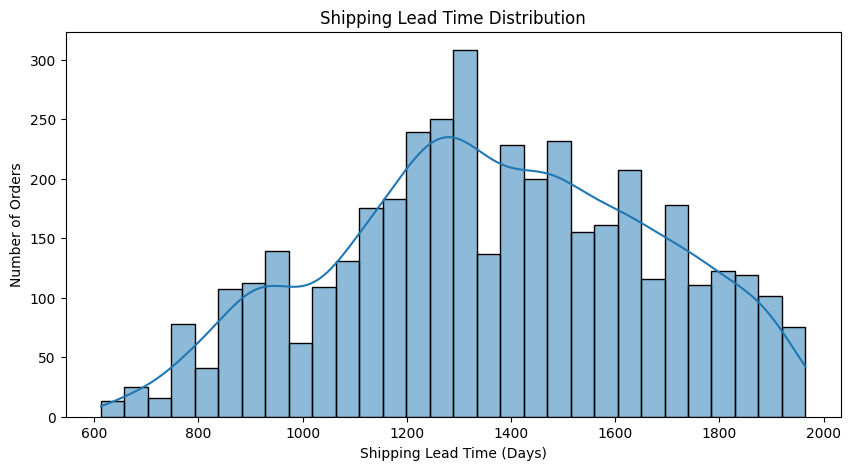

In [20]:

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Shipping_Lead_Time"],
    bins=30,
    kde=True
)

plt.title("Shipping Lead Time Distribution")
plt.xlabel("Shipping Lead Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

# Average lead time by shipping mode

In [21]:
ship_mode_analysis = (
    df.groupby("Ship_Mode")["Shipping_Lead_Time"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

display(ship_mode_analysis)

,mean,median,count
Ship_Mode,,,
Same Day,1405.352227,1358.0,247
First Class,1385.604069,1390.0,639
Second Class,1372.392991,1389.0,799
Standard Class,1354.828221,1335.0,2445


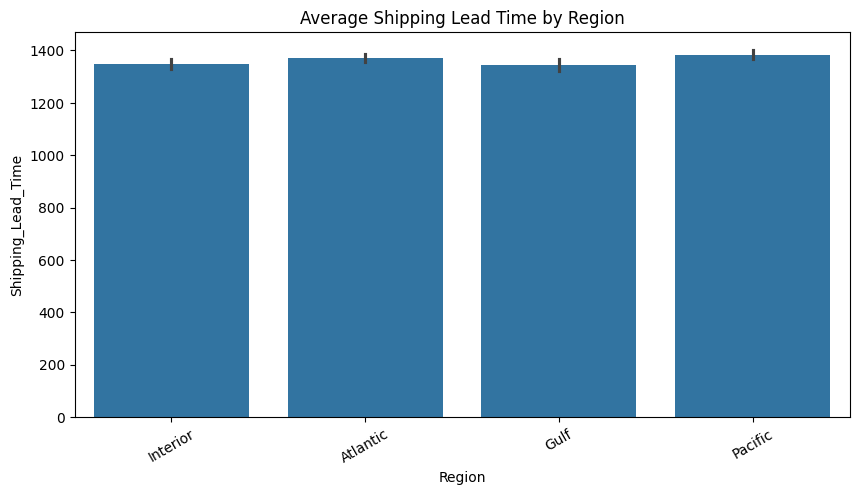

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Region",
    y="Shipping_Lead_Time",
    estimator=np.mean
)

plt.title("Average Shipping Lead Time by Region")
plt.xticks(rotation=30)

plt.show()

# Product performance

In [23]:
product_analysis = (
    df.groupby("Product_Name")
    .agg(
        Orders=("Order_ID", "count"),
        Units=("Units", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross_Profit", "sum"),
        Avg_Lead_Time=("Shipping_Lead_Time", "mean")
    )
    .sort_values("Avg_Lead_Time", ascending=False)
)

display(product_analysis.head(20))

,Orders,Units,Sales,Gross_Profit,Avg_Lead_Time
Product_Name,,,,,
SweeTARTS,3,11,16.50,7.70,1592.000000
Laffy Taffy,2,4,7.96,4.96,1545.500000
Fizzy Lifting Drinks,1,4,15.00,9.00,1489.000000
Lickable Wallpaper,35,152,3040.00,1520.00,1448.514286
Hair Toffee,2,7,31.50,24.50,1425.500000
Kazookles,30,121,393.25,30.25,1380.700000
Wonka Bar - Triple Dazzle Caramel,792,2949,11058.75,7225.05,1380.000000
Wonka Gum,57,203,253.75,131.95,1371.789474
Wonka Bar - Nutty Crunch Surprise,748,2834,9890.66,7056.66,1367.816845


# Create factory coordinates

In [24]:
factory_coords = pd.DataFrame({
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],
    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
})

display(factory_coords)

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


# Product/factory mapping

In [25]:
product_factory = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",

    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",

    "Hair Toffee": "The Other Factory",

    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",

    "Kazookles": "The Other Factory"
}

df["Current_Factory"] = (
    df["Product_Name"]
    .map(product_factory)
)

print(
    "Products without factory mapping:",
    df["Current_Factory"].isna().sum()
)

Products without factory mapping: 0


# Create region coordinates

In [26]:
region_centers = {
    "Pacific": (36.7783, -119.4179),  # Mapped from 'West'
    "Atlantic": (40.7128, -74.0060), # Mapped from 'East'
    "Interior": (41.8781, -87.6298), # Mapped from 'Central'
    "Gulf": (29.7604, -95.3698)    # Mapped from 'South'
}

In [27]:
print(df["Region"].unique())

['Interior' 'Atlantic' 'Gulf' 'Pacific']


# Assign destination coordinates

In [28]:
df["Destination_Latitude"] = df["Region"].map(
    lambda x: region_centers.get(x, (np.nan, np.nan))[0]
)

df["Destination_Longitude"] = df["Region"].map(
    lambda x: region_centers.get(x, (np.nan, np.nan))[1]
)

# Factory coordinates in dataset

In [29]:
factory_lat = dict(
    zip(
        factory_coords["Factory"],
        factory_coords["Latitude"]
    )
)

factory_lon = dict(
    zip(
        factory_coords["Factory"],
        factory_coords["Longitude"]
    )
)

df["Factory_Latitude"] = df["Current_Factory"].map(factory_lat)

df["Factory_Longitude"] = df["Current_Factory"].map(factory_lon)

#Haversine distance

In [30]:
def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c

#Calculate current factory distance

In [31]:
df["Shipping_Distance_KM"] = haversine_distance(
    df["Factory_Latitude"],
    df["Factory_Longitude"],
    df["Destination_Latitude"],
    df["Destination_Longitude"]
)

df["Shipping_Distance_KM"] = (
    df["Shipping_Distance_KM"]
    .fillna(df["Shipping_Distance_KM"].median())
)

display(
    df[
        [
            "Product_Name",
            "Current_Factory",
            "Region",
            "Shipping_Distance_KM"
        ]
    ].head()
)

,Product_Name,Current_Factory,Region,Shipping_Distance_KM
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,577.946401
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,577.946401
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,2116.535008
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,2116.535008
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,631.217417


#Prepare modeling data

In [32]:
model_features = [
    "Product_Name",
    "Division",
    "Region",
    "Ship_Mode",
    "Units",
    "Sales",
    "Cost",
    "Gross_Profit",
    "Profit_Margin",
    "Shipping_Distance_KM",
    "Order_Month",
    "Order_DayOfWeek"
]

target = "Shipping_Lead_Time"

model_df = df[
    model_features + [target]
].copy()

model_df = model_df.dropna()

X = model_df[model_features]

y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4130, 12)
y shape: (4130,)


#Train/test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (3304, 12)
Testing: (826, 12)


#Preprocessing

In [35]:
categorical_features = [
    "Product_Name",
    "Division",
    "Region",
    "Ship_Mode"
]

numerical_features = [
    "Units",
    "Sales",
    "Cost",
    "Gross_Profit",
    "Profit_Margin",
    "Shipping_Distance_KM",
    "Order_Month",
    "Order_DayOfWeek"
]

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Model Training

In [36]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Model Evaluation

In [37]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 221.29
Mean Squared Error (MSE): 75400.13
Root Mean Squared Error (RMSE): 274.59
R-squared (R2): 0.20


#Train and evaluate models

In [38]:
results = []

trained_models = {}

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipeline


model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    "RMSE"
)

display(model_results)

,Model,MAE,RMSE,R2
1,Random Forest,221.294920,274.590848,0.204624
2,Gradient Boosting,227.218579,279.527818,0.175766
0,Linear Regression,237.536670,290.900106,0.107336


# Select best model

In [39]:
best_model_name = model_results.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Random Forest


# Actual vs predicted

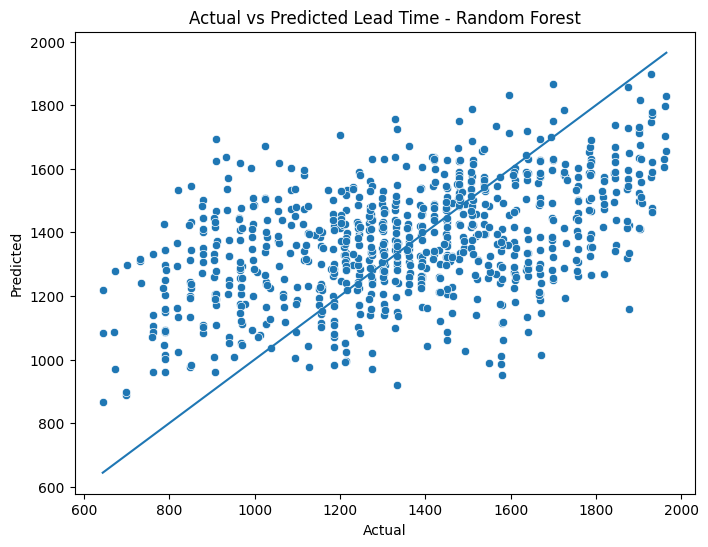

In [40]:
predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=prediction_df,
    x="Actual",
    y="Predicted"
)

plt.plot(
    [
        prediction_df["Actual"].min(),
        prediction_df["Actual"].max()
    ],
    [
        prediction_df["Actual"].min(),
        prediction_df["Actual"].max()
    ]
)

plt.title(
    f"Actual vs Predicted Lead Time - {best_model_name}"
)

plt.show()

#Route performance dataset

In [41]:
route_df = (
    df.groupby(
        [
            "Region",
            "Ship_Mode",
            "Division"
        ]
    )
    .agg(
        Avg_Lead_Time=(
            "Shipping_Lead_Time",
            "mean"
        ),

        Avg_Distance=(
            "Shipping_Distance_KM",
            "mean"
        ),

        Avg_Profit_Margin=(
            "Profit_Margin",
            "mean"
        ),

        Orders=(
            "Order_ID",
            "count"
        )
    )
    .reset_index()
)

display(route_df.head())

,Region,Ship_Mode,Division,Avg_Lead_Time,Avg_Distance,Avg_Profit_Margin,Orders
0,Atlantic,First Class,Chocolate,1370.604061,2273.635312,0.674799,197
1,Atlantic,First Class,Other,1425.500000,1387.565386,0.436154,6
2,Atlantic,First Class,Sugar,1395.000000,1748.641024,0.611558,2
3,Atlantic,Same Day,Chocolate,1322.633333,2024.307151,0.670358,60
4,Atlantic,Same Day,Other,1269.000000,1391.002439,0.288462,2


#KMeans clustering

In [42]:
cluster_features = [
    "Avg_Lead_Time",
    "Avg_Distance",
    "Avg_Profit_Margin"
]

scaler = StandardScaler()

cluster_matrix = scaler.fit_transform(
    route_df[cluster_features]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

route_df["Route_Cluster"] = (
    kmeans.fit_predict(cluster_matrix)
)

display(route_df)

,Region,Ship_Mode,Division,Avg_Lead_Time,Avg_Distance,Avg_Profit_Margin,Orders,Route_Cluster
0,Atlantic,First Class,Chocolate,1370.604061,2273.635312,0.674799,197,0
1,Atlantic,First Class,Other,1425.500000,1387.565386,0.436154,6,2
2,Atlantic,First Class,Sugar,1395.000000,1748.641024,0.611558,2,0
3,Atlantic,Same Day,Chocolate,1322.633333,2024.307151,0.670358,60,0
4,Atlantic,Same Day,Other,1269.000000,1391.002439,0.288462,2,1
5,Atlantic,Second Class,Chocolate,1407.071770,2205.135746,0.675370,209,0
6,Atlantic,Second Class,Other,1365.875000,1392.291334,0.240577,8,2
7,Atlantic,Second Class,Sugar,1729.000000,1748.641024,0.466667,1,3
8,Atlantic,Standard Class,Chocolate,1363.819742,2208.882380,0.674318,699,0
9,Atlantic,Standard Class,Other,1460.720000,1388.321538,0.407262,25,2


#Create all factory scenarios

In [43]:
factory_names = factory_coords["Factory"].tolist()

products = df["Product_Name"].dropna().unique()

scenario_rows = []

for product in products:

    product_data = df[
        df["Product_Name"] == product
    ]

    if len(product_data) == 0:
        continue

    base_row = product_data.iloc[0]

    for factory in factory_names:

        scenario_rows.append({

            "Product_Name": product,

            "Division": base_row["Division"],

            "Region": base_row["Region"],

            "Ship_Mode": base_row["Ship_Mode"],

            "Units": base_row["Units"],

            "Sales": base_row["Sales"],

            "Cost": base_row["Cost"],

            "Gross_Profit": base_row["Gross_Profit"],

            "Profit_Margin": base_row["Profit_Margin"],

            "Order_Month": base_row["Order_Month"],

            "Order_DayOfWeek":
                base_row["Order_DayOfWeek"],

            "Factory": factory,

            "Factory_Latitude":
                factory_lat[factory],

            "Factory_Longitude":
                factory_lon[factory],

            "Destination_Latitude":
                base_row["Destination_Latitude"],

            "Destination_Longitude":
                base_row["Destination_Longitude"]
        })


scenario_df = pd.DataFrame(
    scenario_rows
)

display(scenario_df.head())

,Product_Name,Division,Region,Ship_Mode,Units,Sales,Cost,Gross_Profit,Profit_Margin,Order_Month,Order_DayOfWeek,Factory,Factory_Latitude,Factory_Longitude,Destination_Latitude,Destination_Longitude
0,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.5,2.28,4.22,0.649231,3,4,Lot's O' Nuts,32.881893,-111.768036,41.8781,-87.6298
1,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.5,2.28,4.22,0.649231,3,4,Wicked Choccy's,32.076176,-81.088371,41.8781,-87.6298
2,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.5,2.28,4.22,0.649231,3,4,Sugar Shack,48.119140,-96.181150,41.8781,-87.6298
3,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.5,2.28,4.22,0.649231,3,4,Secret Factory,41.446333,-90.565487,41.8781,-87.6298
4,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.5,2.28,4.22,0.649231,3,4,The Other Factory,35.117500,-89.971107,41.8781,-87.6298


#Calculate scenario distance

In [44]:
scenario_df["Shipping_Distance_KM"] = (
    haversine_distance(
        scenario_df["Factory_Latitude"],
        scenario_df["Factory_Longitude"],
        scenario_df["Destination_Latitude"],
        scenario_df["Destination_Longitude"]
    )
)

display(
    scenario_df[
        [
            "Product_Name",
            "Factory",
            "Shipping_Distance_KM"
        ]
    ].head(20)
)

,Product_Name,Factory,Shipping_Distance_KM
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,2116.535008
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,577.946401
2,Wonka Bar - Milk Chocolate,Sugar Shack,670.181589
3,Wonka Bar - Milk Chocolate,Secret Factory,243.857413
4,Wonka Bar - Milk Chocolate,The Other Factory,203.590257
5,Wonka Bar - Triple Dazzle Caramel,Lot's O' Nuts,2116.535008
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,577.946401
7,Wonka Bar - Triple Dazzle Caramel,Sugar Shack,670.181589
8,Wonka Bar - Triple Dazzle Caramel,Secret Factory,243.857413
9,Wonka Bar - Triple Dazzle Caramel,The Other Factory,203.590257


#Predict lead time for every scenario

In [45]:
scenario_X = scenario_df[model_features].copy()

scenario_df["Predicted_Lead_Time"] = (
    best_model.predict(scenario_X)
)

scenario_df["Predicted_Lead_Time"] = (
    scenario_df["Predicted_Lead_Time"]
    .clip(lower=0)
)

display(
    scenario_df[
        [
            "Product_Name",
            "Factory",
            "Predicted_Lead_Time"
        ]
    ].head(20)
)

,Product_Name,Factory,Predicted_Lead_Time
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,1367.7180
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,1081.5990
2,Wonka Bar - Milk Chocolate,Sugar Shack,1244.7980
3,Wonka Bar - Milk Chocolate,Secret Factory,1076.3240
4,Wonka Bar - Milk Chocolate,The Other Factory,1083.8140
5,Wonka Bar - Triple Dazzle Caramel,Lot's O' Nuts,971.7000
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,955.3700
7,Wonka Bar - Triple Dazzle Caramel,Sugar Shack,974.5000
8,Wonka Bar - Triple Dazzle Caramel,Secret Factory,961.9700
9,Wonka Bar - Triple Dazzle Caramel,The Other Factory,961.9700


#Add current factory

In [46]:
scenario_df["Current_Factory"] = (
    scenario_df["Product_Name"]
    .map(product_factory)
)

#Calculate improvements

In [47]:
current_lead_times = (
    scenario_df[
        scenario_df["Factory"] ==
        scenario_df["Current_Factory"]
    ][
        [
            "Product_Name",
            "Predicted_Lead_Time"
        ]
    ]
    .rename(
        columns={
            "Predicted_Lead_Time":
            "Current_Predicted_Lead_Time"
        }
    )
)

scenario_df = scenario_df.merge(
    current_lead_times,
    on="Product_Name",
    how="left"
)

#Lead-time reduction

In [48]:
scenario_df["Lead_Time_Reduction_Days"] = (
    scenario_df["Current_Predicted_Lead_Time"]
    -
    scenario_df["Predicted_Lead_Time"]
)

scenario_df["Lead_Time_Reduction_Percent"] = np.where(
    scenario_df["Current_Predicted_Lead_Time"] > 0,

    (
        scenario_df["Lead_Time_Reduction_Days"]
        /
        scenario_df["Current_Predicted_Lead_Time"]
    ) * 100,

    0
)

#Distance comparison

In [49]:
current_distances = (
    scenario_df[
        scenario_df["Factory"] ==
        scenario_df["Current_Factory"]
    ][
        [
            "Product_Name",
            "Shipping_Distance_KM"
        ]
    ]
    .rename(
        columns={
            "Shipping_Distance_KM":
            "Current_Distance_KM"
        }
    )
)

scenario_df = scenario_df.merge(
    current_distances,
    on="Product_Name",
    how="left"
)

scenario_df["Distance_Change_KM"] = (
    scenario_df["Shipping_Distance_KM"]
    -
    scenario_df["Current_Distance_KM"]
)

#Estimated logistics impact

In [50]:
LOGISTICS_COST_PER_KM_PER_UNIT = 0.02

In [51]:
scenario_df["Estimated_Logistics_Impact"] = (
    scenario_df["Distance_Change_KM"]
    *
    scenario_df["Units"]
    *
    LOGISTICS_COST_PER_KM_PER_UNIT
)

#Create recommendation score

In [52]:
def calculate_score(
    lead_time_reduction,
    logistics_impact,
    risk_penalty=0
):

    speed_score = lead_time_reduction

    profit_score = -logistics_impact

    return (
        speed_score * 0.6
        +
        profit_score * 0.4
        -
        risk_penalty
    )

#Risk calculation

In [53]:
scenario_df["Risk_Level"] = np.select(
    [
        scenario_df["Lead_Time_Reduction_Percent"] < 0,

        scenario_df["Lead_Time_Reduction_Percent"].between(
            0, 10
        ),

        scenario_df["Lead_Time_Reduction_Percent"] > 10
    ],

    [
        "High",
        "Medium",
        "Low"
    ],

    default="Medium"
)

#Recommendation score

In [54]:
scenario_df["Risk_Penalty"] = (
    scenario_df["Risk_Level"]
    .map({
        "Low": 0,
        "Medium": 5,
        "High": 15
    })
)

scenario_df["Recommendation_Score"] = (
    scenario_df.apply(
        lambda row:
        calculate_score(
            row["Lead_Time_Reduction_Percent"],
            row["Estimated_Logistics_Impact"],
            row["Risk_Penalty"]
        ),
        axis=1
    )
)

# Confidence Score

In [55]:
best_rmse = model_results.iloc[0]["RMSE"]
best_r2 = model_results.iloc[0]["R2"]

confidence_base = max(
    0,
    min(
        100,
        best_r2 * 100
    )
)

scenario_df["Scenario_Confidence_Score"] = (
    confidence_base
)

#Remove current factory

In [56]:
alternative_scenarios = scenario_df[
    scenario_df["Factory"] !=
    scenario_df["Current_Factory"]
].copy()

#Rank recommendations

In [57]:
recommendations = (
    alternative_scenarios
    .sort_values(
        [
            "Product_Name",
            "Recommendation_Score"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    recommendations[
        [
            "Product_Name",
            "Current_Factory",
            "Factory",
            "Predicted_Lead_Time",
            "Lead_Time_Reduction_Days",
            "Lead_Time_Reduction_Percent",
            "Estimated_Logistics_Impact",
            "Risk_Level",
            "Recommendation_Score"
        ]
    ].head(30)
)

,Product_Name,Current_Factory,Factory,Predicted_Lead_Time,Lead_Time_Reduction_Days,Lead_Time_Reduction_Percent,Estimated_Logistics_Impact,Risk_Level,Recommendation_Score
52,Everlasting Gobstopper,Secret Factory,Sugar Shack,1457.112000,0.000000,0.000000,-28.329211,Medium,6.331685
54,Everlasting Gobstopper,Secret Factory,The Other Factory,1457.112000,0.000000,0.000000,5.954048,Medium,-7.381619
51,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,1478.722000,-21.610000,-1.483071,74.365753,High,-45.636144
50,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,1476.542000,-19.430000,-1.333460,89.916464,High,-51.766661
71,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,1389.320000,26.110000,1.844669,-89.393889,Medium,31.864357
73,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,1411.110000,4.320000,0.305208,-29.023533,Medium,6.792538
74,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,1411.110000,4.320000,0.305208,-28.198640,Medium,6.462581
70,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,1401.530000,13.900000,0.982034,126.310328,Medium,-54.934911
64,Fun Dip,Sugar Shack,The Other Factory,1133.590000,-58.430000,-5.434540,-27.995480,High,-7.062532
63,Fun Dip,Sugar Shack,Secret Factory,1133.590000,-58.430000,-5.434540,-25.579451,High,-8.028944


#BEST RECOMMENDATION FOR EACH PRODUCT

In [58]:
best_recommendations = (
    recommendations
    .sort_values(
        "Recommendation_Score",
        ascending=False
    )
    .groupby("Product_Name")
    .head(1)
    .reset_index(drop=True)
)

display(best_recommendations)

,Product_Name,Division,Region,Ship_Mode,Units,Sales,Cost,Gross_Profit,Profit_Margin,Order_Month,...,Current_Predicted_Lead_Time,Lead_Time_Reduction_Days,Lead_Time_Reduction_Percent,Current_Distance_KM,Distance_Change_KM,Estimated_Logistics_Impact,Risk_Level,Risk_Penalty,Recommendation_Score,Scenario_Confidence_Score
0,Hair Toffee,Sugar,Pacific,Standard Class,5,22.50,5.00,17.50,0.777778,6,...,1322.814583,-30.801667,-2.328495,2640.094958,-1942.586974,-194.258697,High,15,61.306382,20.46238
1,Kazookles,Other,Pacific,Standard Class,4,13.00,12.00,1.00,0.076923,4,...,1343.651000,18.396667,1.369155,2640.094958,-1942.586974,-155.406958,Medium,5,57.984276,20.46238
2,Fizzy Lifting Drinks,Sugar,Atlantic,First Class,4,15.00,6.00,9.00,0.600000,9,...,1415.430000,26.110000,1.844669,1748.641024,-1117.423607,-89.393889,Medium,5,31.864357,20.46238
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,Interior,Standard Class,3,10.47,3.00,7.47,0.713467,4,...,930.925500,-51.606500,-5.543569,2116.535008,-1912.944751,-114.776685,High,15,27.584532,20.46238
4,Wonka Bar -Scrumdiddlyumptious,Chocolate,Interior,Standard Class,3,10.80,3.30,7.50,0.694444,4,...,915.000000,-69.030000,-7.544262,2116.535008,-1912.944751,-114.776685,High,15,26.384117,20.46238
5,Nerds,Sugar,Atlantic,Standard Class,2,3.00,1.60,1.40,0.466667,4,...,1342.211667,98.940000,7.371416,1748.641024,-1117.423607,-44.696944,Medium,5,17.301627,20.46238
6,SweeTARTS,Sugar,Interior,Standard Class,3,4.50,2.40,2.10,0.466667,1,...,1550.574000,112.690000,7.267631,670.181589,-466.591332,-27.995480,Medium,5,10.558771,20.46238
7,Everlasting Gobstopper,Sugar,Gulf,Standard Class,4,40.00,8.00,32.00,0.800000,5,...,1457.112000,0.000000,0.000000,431.487177,-354.115141,-28.329211,Medium,5,6.331685,20.46238
8,Wonka Bar - Fudge Mallows,Chocolate,Gulf,Standard Class,2,7.20,2.40,4.80,0.666667,6,...,993.209333,-69.809000,-7.028629,1555.442977,-1478.070941,-59.122838,High,15,4.431958,20.46238
9,Wonka Bar - Milk Chocolate,Chocolate,Interior,Standard Class,2,6.50,2.28,4.22,0.649231,3,...,1081.599000,5.275000,0.487704,577.946401,-334.088989,-13.363560,Medium,5,0.638046,20.46238


#CONFIDENCE SCORE

In [59]:
best_rmse = model_results.iloc[0]["RMSE"]
best_r2 = model_results.iloc[0]["R2"]

confidence_base = max(
    0,
    min(
        100,
        best_r2 * 100
    )
)

scenario_df["Scenario_Confidence_Score"] = (
    confidence_base
)

#RECOMMENDATION COVERAGE

In [60]:
total_products = df["Product_Name"].nunique()

recommended_products = (
    best_recommendations["Product_Name"]
    .nunique()
)

recommendation_coverage = (
    recommended_products /
    total_products
) * 100

print(
    f"Recommendation Coverage: "
    f"{recommendation_coverage:.2f}%"
)

Recommendation Coverage: 100.00%


#FINAL KPI TABLE

In [61]:
avg_lead_reduction = (
    best_recommendations[
        "Lead_Time_Reduction_Percent"
    ].mean()
)

avg_profit_impact = (
    best_recommendations[
        "Estimated_Logistics_Impact"
    ].mean()
)

# Ensure 'Scenario_Confidence_Score' is present in best_recommendations
best_recommendations["Scenario_Confidence_Score"] = confidence_base

avg_confidence = (
    best_recommendations[
        "Scenario_Confidence_Score"
    ].mean()
)

kpi_df = pd.DataFrame({
    "KPI": [
        "Lead Time Reduction (%)",
        "Profit/Logistics Impact",
        "Scenario Confidence Score",
        "Recommendation Coverage (%)"
    ],

    "Value": [
        avg_lead_reduction,
        avg_profit_impact,
        avg_confidence,
        recommendation_coverage
    ]
})

display(kpi_df)

,KPI,Value
0,Lead Time Reduction (%),-1.199182
1,Profit/Logistics Impact,-61.129165
2,Scenario Confidence Score,20.462380
3,Recommendation Coverage (%),100.000000


#SAVE PROJECT OUTPUTS

In [ ]:
os.makedirs("nassau_project", exist_ok=True)

df.to_csv(
    "nassau_project/cleaned_nassau_data.csv",
    index=False
)

scenario_df.to_csv(
    "nassau_project/factory_scenarios.csv",
    index=False
)

best_recommendations.to_csv(
    "nassau_project/recommendations.csv",
    index=False
)

route_df.to_csv(
    "nassau_project/route_clusters.csv",
    index=False
)

model_results.to_csv(
    "nassau_project/model_results.csv",
    index=FalseA
)

kpi_df.to_csv(
    "nassau_project/kpis.csv",
    index=False
)

joblib.dump(
    best_model,
    "nassau_project/best_lead_time_model.pkl"
)

joblib.dump(
    factory_coords,
    "nassau_project/factory_coordinates.pkl"
)

print("All project files saved successfully.")

All project files saved successfully.
